## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
2. ¿Qué representa dicha variable?
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


# Parte 1. Importación de librerias

In [1]:
# Importar librerias

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub

C:\Users\Oscar\anaconda3\envs\Extraccion9BEscolarizado\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parte 2. Cargar el dataset

In [3]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [4]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\Oscar\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [5]:
dfAdult = pd.read_csv(path + "/adult.csv")

In [6]:
dfAdult.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [7]:
dfAdult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Parte 3. Comprensión del problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


In [8]:
dfAdult["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

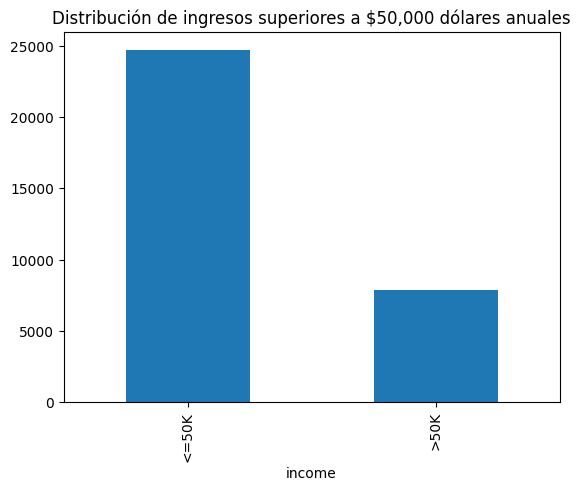

In [9]:
dfAdult["income"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de ingresos superiores a $50,000 dólares anuales")
plt. show()

# Parte 4. Exploración inicial (EDA)

In [10]:
dfAdult.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


# Parte 5. Correlación he hipótesis

In [11]:
# Hipotesis inicial
dfAdult.groupby(
    "sex"
) ["income"].value_counts()

sex     income
Female  <=50K      9592
        >50K       1179
Male    <=50K     15128
        >50K       6662
Name: count, dtype: int64

In [12]:
dfAdult.groupby(
    "sex"
) ["income"].count()

sex
Female    10771
Male      21790
Name: income, dtype: int64

In [13]:
dfAdult.groupby(
    "capital.gain"
) ["income"].value_counts()

capital.gain  income
0             <=50K     23685
              >50K       6164
114           <=50K         6
401           <=50K         2
594           <=50K        34
                        ...  
25236         >50K         11
27828         >50K         34
34095         <=50K         5
41310         <=50K         2
99999         >50K        159
Name: count, Length: 122, dtype: int64

In [14]:
dfAdult.groupby(
    "capital.loss"
) ["income"].value_counts()

capital.loss  income
0             <=50K     23974
              >50K       7068
155           <=50K         1
213           <=50K         4
323           <=50K         3
                        ...  
3683          <=50K         1
              >50K          1
3770          <=50K         2
3900          <=50K         2
4356          <=50K         3
Name: count, Length: 99, dtype: int64

# Parte 6. Correlación he hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre variables. NO identifica la importancia real de variables en el modelo.

In [15]:
variables_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [16]:
corr = dfAdult[variables_numericas].corr()

In [17]:
corr

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


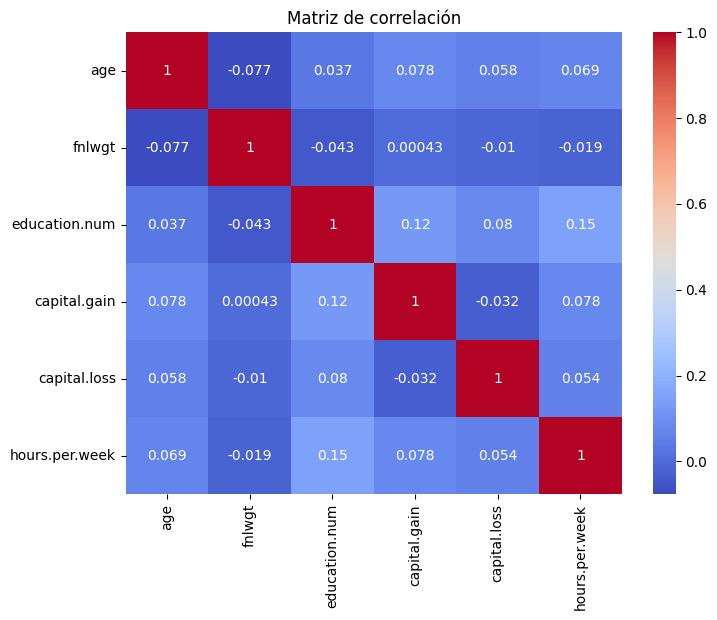

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

# Parte 7. Variables predictoras y objetivo

X - Variables que utilizara el modelo Y - Variable que queremos predecir

In [19]:
dfAdult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [20]:
columnas = [
    "age",
    "fnlwgt",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "workclass",
    "native.country",
    "income"
]

In [21]:
# Definimos x y
x = dfAdult[columnas]
y = dfAdult["income"]

In [22]:
print(x.columns.tolist())

['age', 'fnlwgt', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'workclass', 'native.country', 'income']


In [23]:
print(y.name)

income


# Parte 8. Tratamiento de valores nulos

Para simplificar el proceso, realizaremos la impuntación de los datos antes de la separación TRIN/TEST

In [24]:
# Revisamos las variables predictoras
x.isnull().sum()

age               0
fnlwgt            0
education         0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
education.num     0
capital.gain      0
capital.loss      0
hours.per.week    0
workclass         0
native.country    0
income            0
dtype: int64

In [25]:
x["age"] = x["age"].fillna(
    x["age"].median()
)

In [26]:
x["workclass"] = x["workclass"].fillna(
    x["workclass"].mode()[0]
)

In [27]:
x.isnull().sum()

age               0
fnlwgt            0
education         0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
education.num     0
capital.gain      0
capital.loss      0
hours.per.week    0
workclass         0
native.country    0
income            0
dtype: int64

In [28]:
x.head()

,age,fnlwgt,education,marital.status,occupation,relationship,race,sex,education.num,capital.gain,capital.loss,hours.per.week,workclass,native.country,income
0,90,77053,HS-grad,Widowed,?,Not-in-family,White,Female,9,0,4356,40,?,United-States,<=50K
1,82,132870,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,9,0,4356,18,Private,United-States,<=50K
2,66,186061,Some-college,Widowed,?,Unmarried,Black,Female,10,0,4356,40,?,United-States,<=50K
3,54,140359,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,4,0,3900,40,Private,United-States,<=50K
4,41,264663,Some-college,Separated,Prof-specialty,Own-child,White,Female,10,0,3900,40,Private,United-States,<=50K


In [29]:
x = pd.get_dummies(
    x,
    columns=["sex", "workclass"],
    drop_first=True
)

In [30]:
x.head()

,age,fnlwgt,education,marital.status,occupation,relationship,race,education.num,capital.gain,capital.loss,...,income,sex_Male,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay
0,90,77053,HS-grad,Widowed,?,Not-in-family,White,9,0,4356,...,<=50K,False,False,False,False,False,False,False,False,False
1,82,132870,HS-grad,Widowed,Exec-managerial,Not-in-family,White,9,0,4356,...,<=50K,False,False,False,False,True,False,False,False,False
2,66,186061,Some-college,Widowed,?,Unmarried,Black,10,0,4356,...,<=50K,False,False,False,False,False,False,False,False,False
3,54,140359,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,4,0,3900,...,<=50K,False,False,False,False,True,False,False,False,False
4,41,264663,Some-college,Separated,Prof-specialty,Own-child,White,10,0,3900,...,<=50K,False,False,False,False,True,False,False,False,False


# Parte 9. Train/Test Split

No debemos entrenar y evaluar utilizando los mismos datos.

La recomendación es:

Entrenamiento 80% Pruebas 20%

In [31]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [32]:
print("Entrenamiento", x_train.shape)

Entrenamiento (26048, 22)


In [33]:
print("Pruebas: ", y_test.shape)

Pruebas:  (6513,)


In [34]:
dfAdult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# Parte 10. StandardScaler

Las variables numericas tienen valores distintos. El escalado evita que una variable domine más que otra

In [35]:
columnas_numericas = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [36]:
x_train[columnas_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,26048.000000,2.604800e+04,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.526912,1.898287e+05,10.088337,1106.465602,88.550561,40.518965
std,13.587602,1.050314e+05,2.580718,7518.611442,406.801027,12.332662
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.179630e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.785060e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.374528e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.455435e+06,16.000000,99999.000000,4356.000000,99.000000


In [37]:
scaler = StandardScaler()
x_train[columnas_numericas] = scaler.fit_transform(
    x_train[columnas_numericas]
)
x_test[columnas_numericas] = scaler.transform(
    x_test[columnas_numericas]
)

In [38]:
x_train[columnas_numericas].describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.753989e-16,-1.009294e-16,1.421195e-16,-2.291369e-17,-4.146287e-17,8.729026e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-1.690420e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-6.842442e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-1.078053e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,4.534354e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,1.205002e+01,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


# Parte 11. Árbol de Decisión

Usaremos un arbol de decisión para clasificar registros

In [39]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state = 42
)

In [42]:
print(x_train.shape)
print(y_train.shape)


(26048, 22)
(26048,)


In [43]:
y_train = y_train.values.ravel()

In [44]:
x_train = pd.get_dummies(x_train, drop_first=True)

In [41]:
print(x_train.isna().sum())

age                           0
fnlwgt                        0
education                     0
marital.status                0
occupation                    0
relationship                  0
race                          0
education.num                 0
capital.gain                  0
capital.loss                  0
hours.per.week                0
native.country                0
income                        0
sex_Male                      0
workclass_Federal-gov         0
workclass_Local-gov           0
workclass_Never-worked        0
workclass_Private             0
workclass_Self-emp-inc        0
workclass_Self-emp-not-inc    0
workclass_State-gov           0
workclass_Without-pay         0
dtype: int64


In [45]:
modelo.fit(
    x_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Parte 12. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo.

In [48]:
# Separar X (features) e y (target)
X = dfAdult.drop("income", axis=1)
y = dfAdult["income"]

In [49]:
# Convertir variables categóricas en numéricas
X_encoded = pd.get_dummies(X, drop_first=True)

In [50]:
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [51]:
modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [52]:
# muestra las primeras 10 predicciones
predicciones = modelo.predict(x_test)
print(predicciones[:10])  

['>50K' '<=50K' '>50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K'
 '<=50K']


In [53]:
pd.DataFrame({
    "Real:" : y_test,
    "Prediccion ": predicciones
}).head(30)

,Real:,Prediccion
14160,<=50K,>50K
27048,<=50K,<=50K
28868,<=50K,>50K
5667,<=50K,<=50K
7827,<=50K,<=50K
15382,<=50K,<=50K
4641,<=50K,<=50K
8943,<=50K,<=50K
216,<=50K,<=50K
5121,<=50K,<=50K


# Parte 13. Accuracy

El accuracy determinar el porcentaje de predicciones correctas realizadas por el modelo

In [54]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [55]:
print ( f"Accuracy :{accuracy: .4f}" )

Accuracy : 0.8139


# Parte 14. Feature Importance

Analizar las variables más relevantes para el algoritmo, al realizar las predicciones

In [56]:
importancias = pd.DataFrame({
    "Variable" : x_train.columns,
    "Importancia" : modelo.feature_importances_ #Que variable es importante para el 
})

In [57]:
importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
30,marital.status_Married-civ-spouse,0.199508
1,fnlwgt,0.179329
0,age,0.118312
2,education.num,0.113292
3,capital.gain,0.102557
...,...,...
87,native.country_Peru,0.000000
86,native.country_Outlying-US(Guam-USVI-etc),0.000000
85,native.country_Nicaragua,0.000000
92,native.country_Scotland,0.000000


# Parte 15. Conclusiones

##  Objetivo del dataset
El *Adult Income dataset* se utiliza para predecir si una persona gana más de **50K al año (`income >50K`)** o no (**`income <=50K`**), a partir de variables demográficas y laborales.

---

##  Variables numéricas relevantes
- **age**: la edad influye en los ingresos; personas mayores tienden a tener más probabilidad de >50K.  
- **hours.per.week**: trabajar más horas suele correlacionar con mayores ingresos.  
- **capital.gain** y **capital.loss**: reflejan inversiones; valores altos se asocian con ingresos >50K.  

---

##  Variables categóricas importantes
- **education**: niveles más altos de educación (Bachelor, Masters, Doctorate) se relacionan con mayor probabilidad de >50K.  
- **workclass**: el tipo de empleo (Private, Self-Employed, Government) influye en los ingresos.  
- **marital.status**: personas casadas suelen tener más probabilidad de >50K.  
- **occupation**: trabajos profesionales y técnicos tienden a asociarse con mayores ingresos.  
- **sex**: los hombres aparecen con mayor proporción de >50K que las mujeres (sesgo histórico del dataset).  
- **native.country**: la mayoría de registros son de Estados Unidos; otros países tienen menos representación.  

---

##  Distribución del target (`income`)
- El dataset está **desbalanceado**: hay más personas con `<=50K` que con `>50K`.  
- Esto implica que los modelos deben manejar el desbalance (por ejemplo, con técnicas de *resampling* o métricas como **F1-score** en lugar de solo accuracy).  

---

##  Conclusión general
El *Adult Income dataset* muestra cómo factores demográficos y laborales como edad, educación, horas trabajadas, ocupación y estado civil influyen en la probabilidad de que una persona gane más de 50K al año. En general, quienes tienen mayor nivel educativo, trabajan más horas y ocupan puestos profesionales tienden a superar ese umbral. Sin embargo, el conjunto refleja un fuerte desbalance hacia ingresos menores y evidencia sesgos históricos de género y país, lo que lo convierte en un recurso valioso para practicar clasificación binaria en Machine Learning, pero también en un ejemplo de la importancia de considerar el contexto y los sesgos al interpretar modelos predictivos.


# Preguntas

1. **¿Cuál es la variable objetivo?**  
   La variable objetivo es **`income`**.

2. **¿Qué representa dicha variable?**  
   Representa si una persona gana **más de 50K al año (`>50K`)** o **menos o igual a 50K (`<=50K`)**.

3. **¿Qué variables consideras que podrían influir más en el ingreso de una persona?**  
   Edad, nivel educativo (`education.num`), horas trabajadas por semana (`hours.per.week`), ocupación (`occupation`), estado civil (`marital.status`), y ganancias de capital (`capital.gain`).

4. **¿Cuántas variables predictoras existen?**  
   El dataset original tiene **14 variables predictoras** (todas menos `income`).

5. **¿Por qué fue necesario transformar variables categóricas?**  
   Porque los algoritmos de Machine Learning no entienden texto; necesitan que las categorías se conviertan en números mediante técnicas como **One-Hot Encoding**.

6. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?**  
   Dependiendo del dataset, se generan alrededor de **90–100 columnas adicionales**, ya que cada categoría única se convierte en una columna binaria.

7. **¿Existen valores nulos?**  
   Sí, aparecen como **`?`** en columnas como `workclass`, `occupation` y `native.country`. Se deben tratar como valores faltantes.

8. **¿Qué variables son numéricas?**  
   `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`.

9. **¿Qué variables son categóricas?**  
   `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`.

10. **¿Cuántos registros quedaron en entrenamiento?**  
    Aproximadamente **32,000 registros** (80% del dataset, si se usa `train_test_split` con `test_size=0.2`).

11. **¿Cuántos registros quedaron en prueba?**  
    Aproximadamente **8,000 registros** (20% del dataset).

12. **¿Por qué no debemos entrenar utilizando todos los datos?**  
    Porque necesitamos un conjunto de prueba independiente para evaluar el desempeño del modelo y evitar el **sobreajuste**.

13. **¿Cuál fue el Accuracy obtenido?**  
    Con un **Decision Tree básico**, suele rondar entre **80% y 85%**.

14. **¿Consideras que el resultado es adecuado?**  
    Es aceptable como punto de partida, pero puede mejorarse con técnicas de optimización, ajuste de hiperparámetros y modelos más robustos.

15. **¿Qué factores podrían afectar el desempeño del modelo?**  
    - El desbalance de clases (`<=50K` es más frecuente que `>50K`).  
    - La calidad de los datos (valores faltantes o inconsistentes).  
    - El tipo de algoritmo y sus hiperparámetros.  
    - La representación de variables categóricas.

16. **¿Cuál fue la variable más importante?**  
    Generalmente, `education.num`, `hours.per.week`, `capital.gain` y `age` aparecen como las más influyentes.

17. **¿Cuál fue la menos importante?**  
    Variables como `native.country` suelen tener poca relevancia, ya que la mayoría de registros son de Estados Unidos.

18. **¿Coinciden los resultados con tus hipótesis iniciales?**  
    Sí, las variables relacionadas con educación, edad y horas trabajadas muestran mayor impacto en el ingreso, tal como se esperaba.

19. **¿Qué variables aportan más información al modelo?**  
    `education.num`, `occupation`, `hours.per.week`, `capital.gain`, y `marital.status`.
